In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import main

In [2]:
def get_selectors(df, target_column):
    selectors = {}
    sel = 0
    for i in range(len(df.columns)):
        if df.columns[i] != target_column:
            sel += df.iloc[:, i].nunique()
        selectors[i] = sel

    return selectors


In [3]:
main.get_healthy_aging_data().shape

(714, 14)

In [4]:
# get_selectors(main.get_depression_data(), main.get_target("Depression")[0])
selectors = {
    "Mushrooms" : get_selectors(main.get_mushrooms_data(), main.get_target("Mushrooms")[0]),
    "Chess" : get_selectors(main.get_chess_data(), main.get_target("Chess")[0]),
    "StudentSuccess" : get_selectors(main.get_student_success_data(), main.get_target("StudentSuccess")[0]),
    "connect4" : get_selectors(main.get_connect4_data(), main.get_target("connect4")[0]),
    "HealthyAging" : get_selectors(main.get_healthy_aging_data(), main.get_target("HealthyAging")[0]),
    "Car" : get_selectors(main.get_car_data(), main.get_target("Car")[0]),
    "Soybean" : get_selectors(main.get_soybean_data(), main.get_target("Soybean")[0]),
    "Dermatology" : get_selectors(main.get_dermatology_data(), main.get_target("Dermatology")[0]),
    "Depression" : get_selectors(main.get_depression_data(), main.get_target("Depression")[0]),
    "Vancomycin" : get_selectors(main.get_vancomycin_data(), main.get_target("Vancomycin")[0]),
    "MIMIC-IV" : get_selectors(main.get_mimic_iv_data(), main.get_target("MIMIC-IV")[0]),
    "Cardio" : get_selectors(main.get_cardio_data(), main.get_target("Cardio")[0]),

}


In [5]:
rows = {
    "Mushrooms": main.get_mushrooms_data().shape[0],
    "Chess": main.get_chess_data().shape[0],
    "StudentSuccess": main.get_student_success_data().shape[0],
    "connect4": main.get_connect4_data().shape[0],
    "HealthyAging": main.get_healthy_aging_data().shape[0],
    "Car": main.get_car_data().shape[0],
    "Soybean": main.get_soybean_data().shape[0],
    "Dermatology": main.get_dermatology_data().shape[0],
    "Depression": main.get_depression_data().shape[0],
    "Vancomycin": main.get_vancomycin_data().shape[0],
    "MIMIC-IV": main.get_mimic_iv_data().shape[0],
    "Cardio": main.get_cardio_data().shape[0],
}
rows

{'Mushrooms': 8124,
 'Chess': 3196,
 'StudentSuccess': 4424,
 'connect4': 67557,
 'HealthyAging': 714,
 'Car': 1728,
 'Soybean': 307,
 'Dermatology': 366,
 'Depression': 502,
 'Vancomycin': 447,
 'MIMIC-IV': 107012,
 'Cardio': 70000}

In [6]:
selectors["Car"]

{0: 0, 1: 4, 2: 8, 3: 12, 4: 15, 5: 18, 6: 21}

In [7]:
{k:max(v.values()) for k,v in selectors.items()}

{'Mushrooms': 116,
 'Chess': 73,
 'StudentSuccess': 458,
 'connect4': 126,
 'HealthyAging': 48,
 'Car': 21,
 'Soybean': 132,
 'Dermatology': 129,
 'Depression': 28,
 'Vancomycin': 37,
 'MIMIC-IV': 206,
 'Cardio': 14}

In [8]:
df = pd.DataFrame(columns = ["Model", "Dataset", "Columns", "Selectors", "Time (s)", "Memory (bytes)"])

for file in os.listdir("./results"):
    if file.endswith(".txt"):
        file_name = file.split(".txt")[0]
        model = file_name.split("_")[0]
        dataset = file_name.split("_")[1]
        columns = int(file_name.split("_")[2])
        try:
            sel = selectors[dataset][columns]
        except KeyError:
            print(f"Dataset {dataset} or columns {columns} not found in selectors dictionary.")
        with open(os.path.join("./results", file), "r") as f:
            try:
                line = f.readline()
                line = line[1:-2]
                line = line.split(", ")
                time = float(line[0])
                memory = int(line[1])
            except Exception as e:
                # print(f"Error reading file {file}: {e}")
                continue
            # line = f.readline()
            # if line != "":
            #     time, memory = eval(line)
        df.loc[len(df)] = [model, dataset, columns, sel, time, memory]

Dataset HealthyAging or columns 14 not found in selectors dictionary.


In [9]:
main.get_chess_data().shape

(3196, 37)

In [10]:
df["Model"] = df["Model"].replace({"SDMapStar": "SDMap*",
                                   "QFinder": "Q-Finder"})

In [11]:
# Only times and memory from maximum number of columns
columns = {d : max(s.keys()) for d,s in selectors.items()}
print(columns)
df_max = df[df.apply(lambda row: row["Columns"] == columns[row["Dataset"]], axis=1)]
df_max

# # df_max

table = df_max.pivot(index=["Dataset"], columns="Model", values=["Time (s)", "Memory (bytes)"])

# Print using scientific notation
pd.set_option('display.float_format', '{:.2e}'.format)
display(table)
print(table.to_latex(float_format="%.2e"))

{'Mushrooms': 21, 'Chess': 36, 'StudentSuccess': 28, 'connect4': 42, 'HealthyAging': 13, 'Car': 6, 'Soybean': 35, 'Dermatology': 33, 'Depression': 8, 'Vancomycin': 9, 'MIMIC-IV': 12, 'Cardio': 6}


Time (s)                                        Memory (bytes)  \
Model               BSD BerryFinder  ExCover Q-Finder   SDMap*            BSD   
Dataset                                                                         
Car            7.30e-02    1.79e-02 1.42e-02 2.34e+01 5.19e-01       1.77e+08   
Cardio         3.16e-01    3.96e-01 1.05e+00 3.54e+03 6.79e+00       2.08e+08   
Chess          3.86e+01    2.97e+02 1.38e+02      NaN      NaN       1.79e+08   
Depression     1.77e-02    3.18e-02 2.99e-01 8.09e+01 5.83e-01       1.76e+08   
Dermatology    1.61e+00    5.24e+01 3.25e-01      NaN      NaN       1.78e+08   
HealthyAging   1.55e-01    6.53e-01 2.70e+00 1.92e+03 1.75e-01       1.77e+08   
MIMIC-IV       1.95e+00    6.72e+01 1.41e+01      NaN 1.91e+02       2.08e+08   
Mushrooms      1.15e+01    1.16e+01 5.19e-01      NaN 5.28e+03       1.80e+08   
StudentSuccess 7.33e+02    2.18e+01 5.77e+01      NaN      NaN       1.83e+08   
Vancomycin     1.93e-01    4.07e-02 2.21e-02 1.06e+02 6.45e-02       1.76e+08   
connect4       1.24e+01    5.48e+03 2.86e+03      NaN      NaN       2.31e+08   

                                                       
Model          BerryFinder  ExCover Q-Finder   SDMap*  
Dataset                                                
Car               1.73e+08 1.75e+08 2.25e+08 1.79e+08  
Cardio            2.06e+08 2.17e+08 7.53e+08 2.08e+08  
Chess             1.79e+08 1.78e+08      NaN      NaN  
Depression        1.72e+08 1.74e+08 2.74e+08 1.77e+08  
Dermatology       1.74e+08 1.74e+08      NaN      NaN  
HealthyAging      1.73e+08 1.75e+08 8.52e+08 1.78e+08  
MIMIC-IV          2.09e+08 2.28e+08      NaN 2.88e+08  
Mushrooms         1.81e+08 1.77e+08      NaN 1.99e+08  
StudentSuccess    1.83e+08 1.86e+08      NaN      NaN  
Vancomycin        1.73e+08 1.73e+08 2.65e+08 1.78e+08  
connect4          2.34e+08 2.23e+08      NaN      NaN

\begin{tabular}{lrrrrrrrrrr}
\toprule
 & \multicolumn{5}{r}{Time (s)} & \multicolumn{5}{r}{Memory (bytes)} \\
Model & BSD & BerryFinder & ExCover & Q-Finder & SDMap* & BSD & BerryFinder & ExCover & Q-Finder & SDMap* \\
Dataset &  &  &  &  &  &  &  &  &  &  \\
\midrule
Car & 7.30e-02 & 1.79e-02 & 1.42e-02 & 2.34e+01 & 5.19e-01 & 1.77e+08 & 1.73e+08 & 1.75e+08 & 2.25e+08 & 1.79e+08 \\
Cardio & 3.16e-01 & 3.96e-01 & 1.05e+00 & 3.54e+03 & 6.79e+00 & 2.08e+08 & 2.06e+08 & 2.17e+08 & 7.53e+08 & 2.08e+08 \\
Chess & 3.86e+01 & 2.97e+02 & 1.38e+02 & NaN & NaN & 1.79e+08 & 1.79e+08 & 1.78e+08 & NaN & NaN \\
Depression & 1.77e-02 & 3.18e-02 & 2.99e-01 & 8.09e+01 & 5.83e-01 & 1.76e+08 & 1.72e+08 & 1.74e+08 & 2.74e+08 & 1.77e+08 \\
Dermatology & 1.61e+00 & 5.24e+01 & 3.25e-01 & NaN & NaN & 1.78e+08 & 1.74e+08 & 1.74e+08 & NaN & NaN \\
HealthyAging & 1.55e-01 & 6.53e-01 & 2.70e+00 & 1.92e+03 & 1.75e-01 & 1.77e+08 & 1.73e+08 & 1.75e+08 & 8.52e+08 & 1.78e+08 \\
MIMIC-IV & 1.95e+00 & 6.72e+01 & 1.41e+0

In [12]:
# Fill any value of Time (s) column greater than 172800 with NaN
table[("Time (s)", "BerryFinder")] = table[("Time (s)", "BerryFinder")].apply(lambda x: x if x <= 172800 else float('nan'))
table[("Time (s)", "BSD")] = table[("Time (s)", "BSD")].apply(lambda x: x if x <= 172800 else float('nan'))
table[("Time (s)", "SDMap*")] = table[("Time (s)", "SDMap*")].apply(lambda x: x if x <= 172800 else float('nan'))
display(table)
print(table.to_latex(float_format="%.2e", na_rep="--"))

Time (s)                                        Memory (bytes)  \
Model               BSD BerryFinder  ExCover Q-Finder   SDMap*            BSD   
Dataset                                                                         
Car            7.30e-02    1.79e-02 1.42e-02 2.34e+01 5.19e-01       1.77e+08   
Cardio         3.16e-01    3.96e-01 1.05e+00 3.54e+03 6.79e+00       2.08e+08   
Chess          3.86e+01    2.97e+02 1.38e+02      NaN      NaN       1.79e+08   
Depression     1.77e-02    3.18e-02 2.99e-01 8.09e+01 5.83e-01       1.76e+08   
Dermatology    1.61e+00    5.24e+01 3.25e-01      NaN      NaN       1.78e+08   
HealthyAging   1.55e-01    6.53e-01 2.70e+00 1.92e+03 1.75e-01       1.77e+08   
MIMIC-IV       1.95e+00    6.72e+01 1.41e+01      NaN 1.91e+02       2.08e+08   
Mushrooms      1.15e+01    1.16e+01 5.19e-01      NaN 5.28e+03       1.80e+08   
StudentSuccess 7.33e+02    2.18e+01 5.77e+01      NaN      NaN       1.83e+08   
Vancomycin     1.93e-01    4.07e-02 2.21e-02 1.06e+02 6.45e-02       1.76e+08   
connect4       1.24e+01    5.48e+03 2.86e+03      NaN      NaN       2.31e+08   

                                                       
Model          BerryFinder  ExCover Q-Finder   SDMap*  
Dataset                                                
Car               1.73e+08 1.75e+08 2.25e+08 1.79e+08  
Cardio            2.06e+08 2.17e+08 7.53e+08 2.08e+08  
Chess             1.79e+08 1.78e+08      NaN      NaN  
Depression        1.72e+08 1.74e+08 2.74e+08 1.77e+08  
Dermatology       1.74e+08 1.74e+08      NaN      NaN  
HealthyAging      1.73e+08 1.75e+08 8.52e+08 1.78e+08  
MIMIC-IV          2.09e+08 2.28e+08      NaN 2.88e+08  
Mushrooms         1.81e+08 1.77e+08      NaN 1.99e+08  
StudentSuccess    1.83e+08 1.86e+08      NaN      NaN  
Vancomycin        1.73e+08 1.73e+08 2.65e+08 1.78e+08  
connect4          2.34e+08 2.23e+08      NaN      NaN

\begin{tabular}{lrrrrrrrrrr}
\toprule
 & \multicolumn{5}{r}{Time (s)} & \multicolumn{5}{r}{Memory (bytes)} \\
Model & BSD & BerryFinder & ExCover & Q-Finder & SDMap* & BSD & BerryFinder & ExCover & Q-Finder & SDMap* \\
Dataset &  &  &  &  &  &  &  &  &  &  \\
\midrule
Car & 7.30e-02 & 1.79e-02 & 1.42e-02 & 2.34e+01 & 5.19e-01 & 1.77e+08 & 1.73e+08 & 1.75e+08 & 2.25e+08 & 1.79e+08 \\
Cardio & 3.16e-01 & 3.96e-01 & 1.05e+00 & 3.54e+03 & 6.79e+00 & 2.08e+08 & 2.06e+08 & 2.17e+08 & 7.53e+08 & 2.08e+08 \\
Chess & 3.86e+01 & 2.97e+02 & 1.38e+02 & -- & -- & 1.79e+08 & 1.79e+08 & 1.78e+08 & -- & -- \\
Depression & 1.77e-02 & 3.18e-02 & 2.99e-01 & 8.09e+01 & 5.83e-01 & 1.76e+08 & 1.72e+08 & 1.74e+08 & 2.74e+08 & 1.77e+08 \\
Dermatology & 1.61e+00 & 5.24e+01 & 3.25e-01 & -- & -- & 1.78e+08 & 1.74e+08 & 1.74e+08 & -- & -- \\
HealthyAging & 1.55e-01 & 6.53e-01 & 2.70e+00 & 1.92e+03 & 1.75e-01 & 1.77e+08 & 1.73e+08 & 1.75e+08 & 8.52e+08 & 1.78e+08 \\
MIMIC-IV & 1.95e+00 & 6.72e+01 & 1.41e+01 & -- &

In [13]:
dataset_name_mapping = {
    "Car": "Car Evaluation",
    "Chess": "Chess",
    "Cardio": "Cardio",
    "Depression": "Depression",
    "Dermatology": "Dermatology",
    "HealthyAging": "Healthy Aging",
    "MIMIC-IV": "MIMIC-IV",
    "Soybean": "Soybean",
    "Mushrooms": "Mushrooms",
    "StudentSuccess": "Student Success",
    "Vancomycin": "Vancomycin",
    "connect4": "Connect-4"
}

df["Dataset"] = df["Dataset"].replace(dataset_name_mapping)

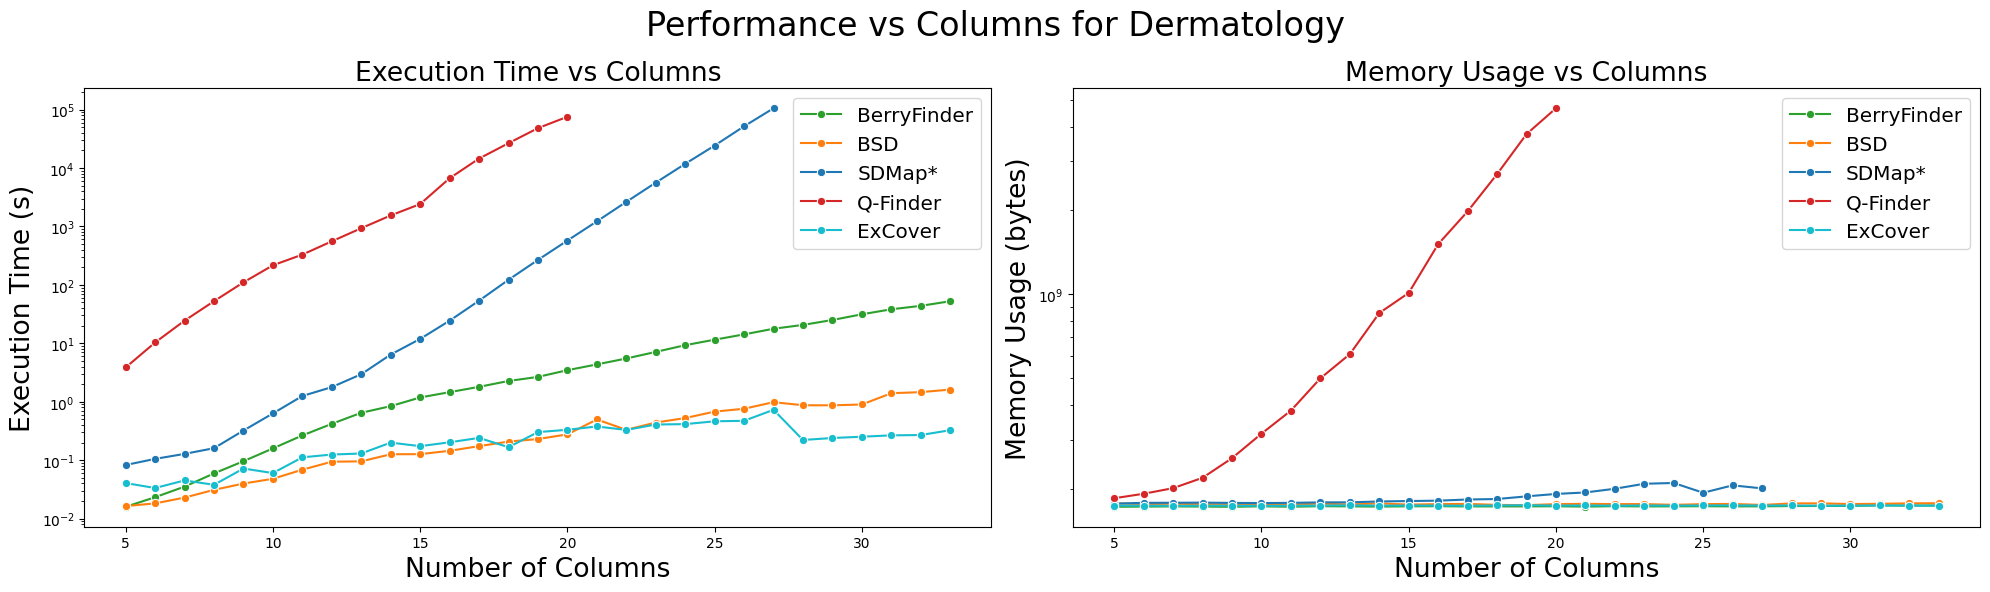

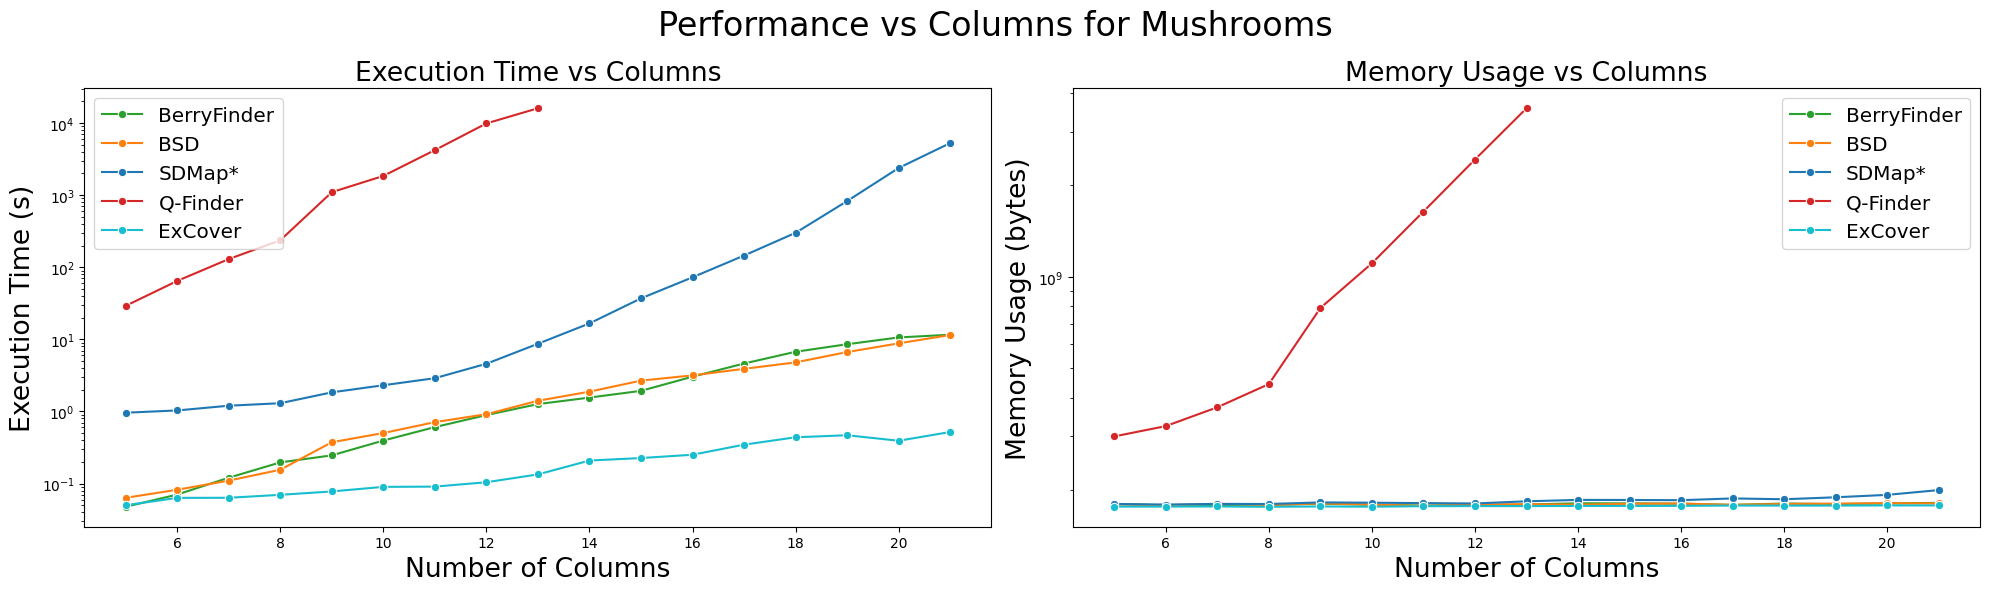

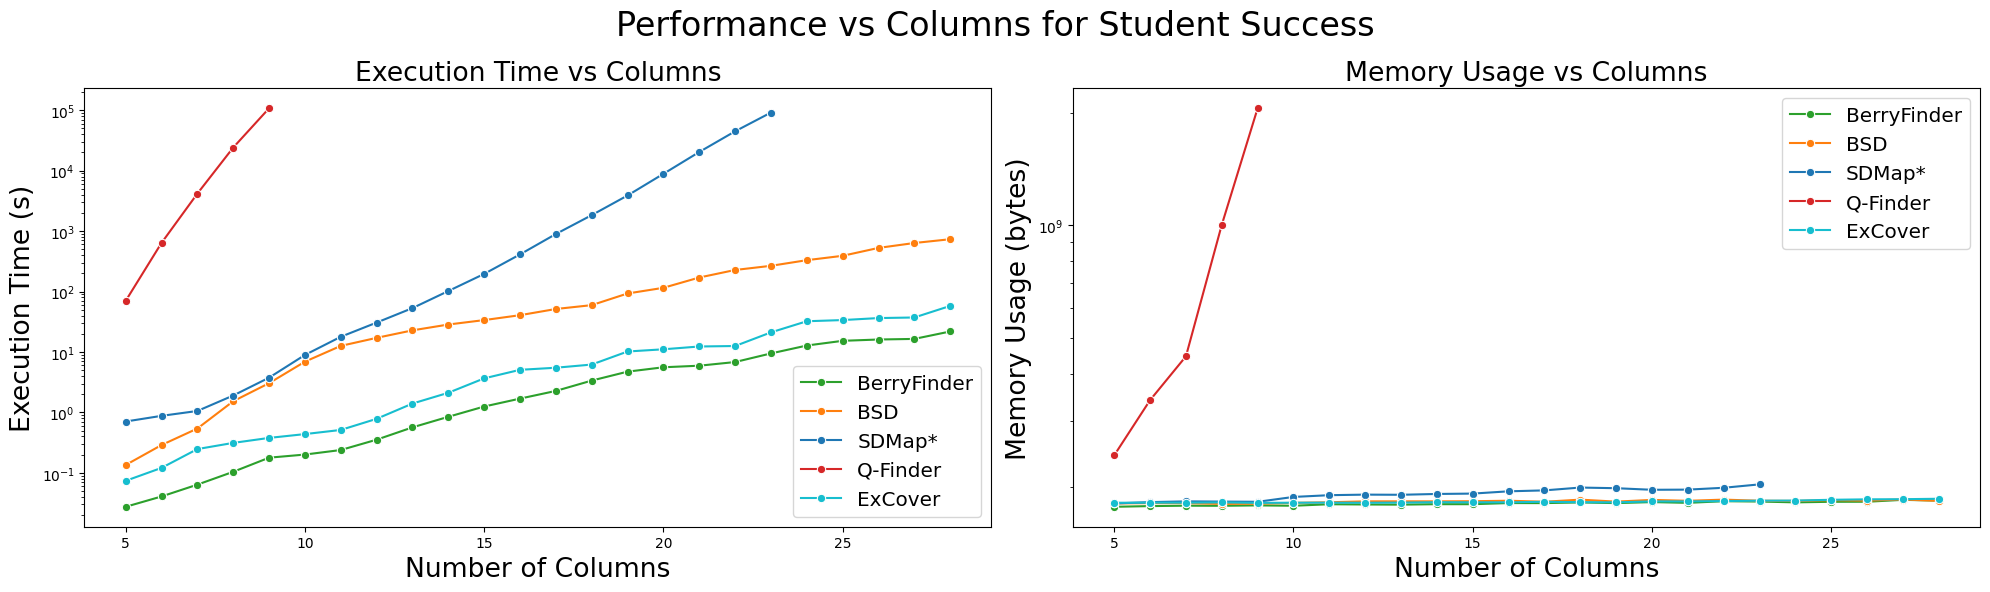

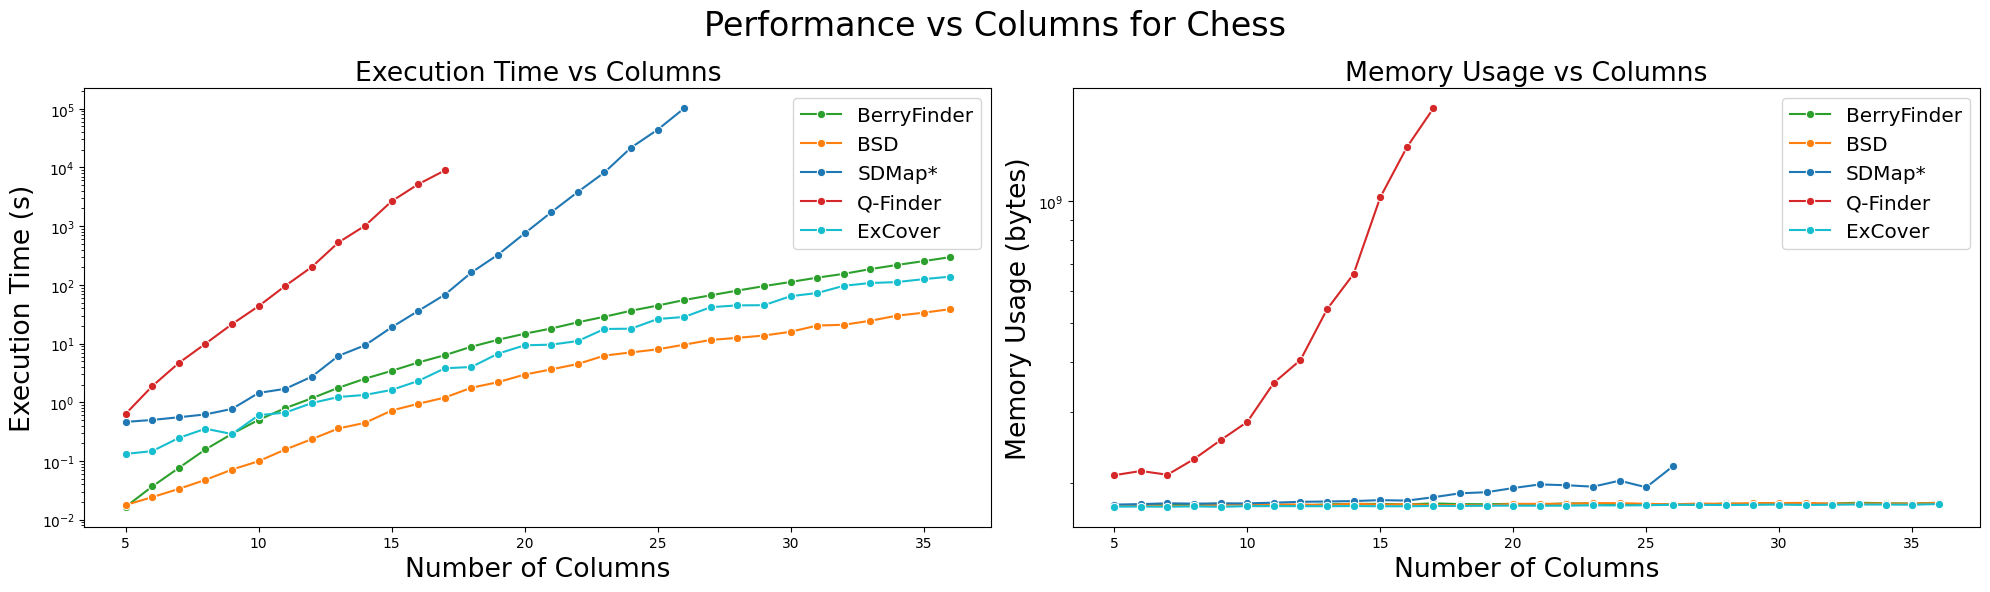

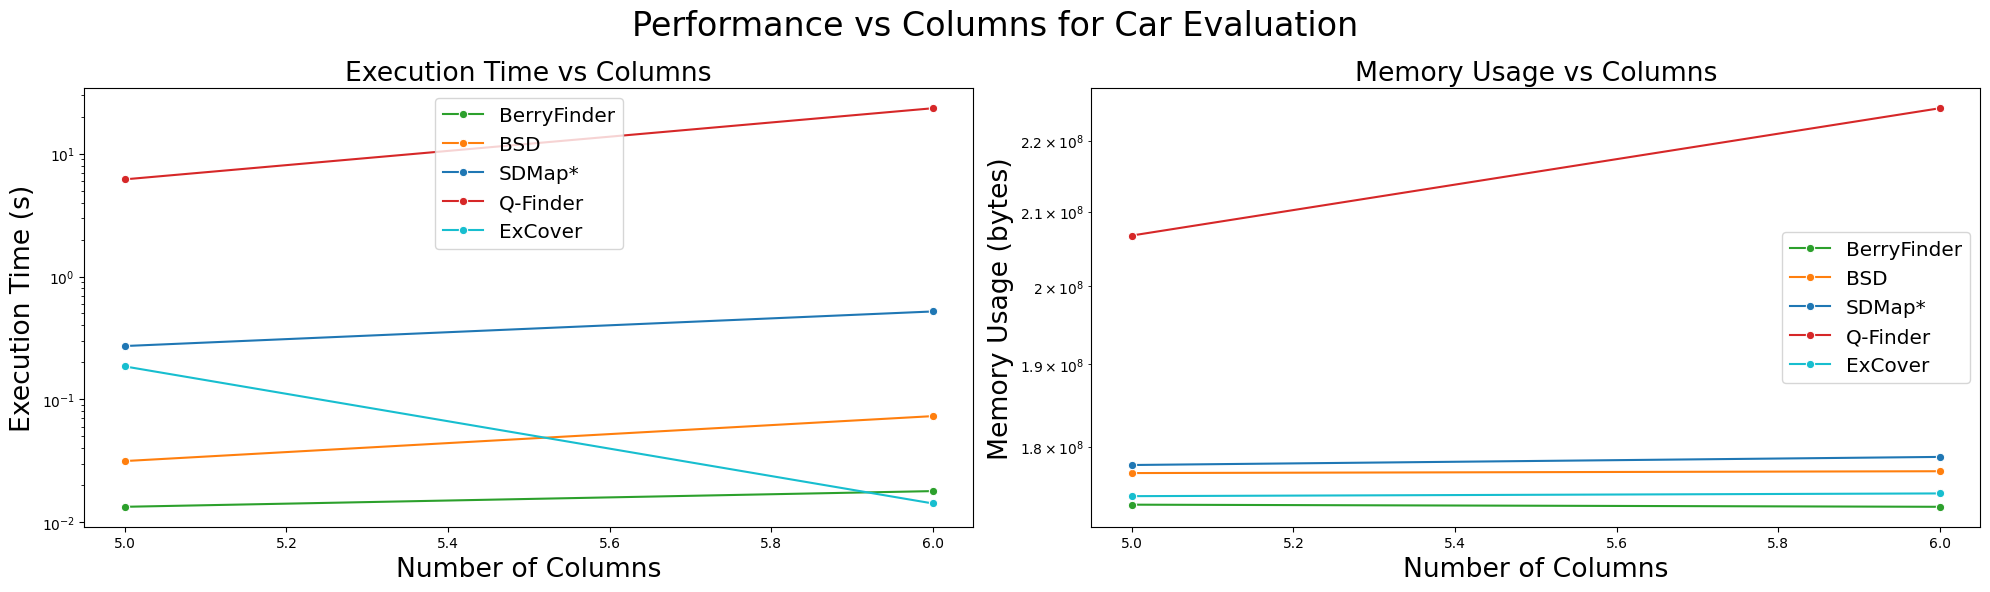

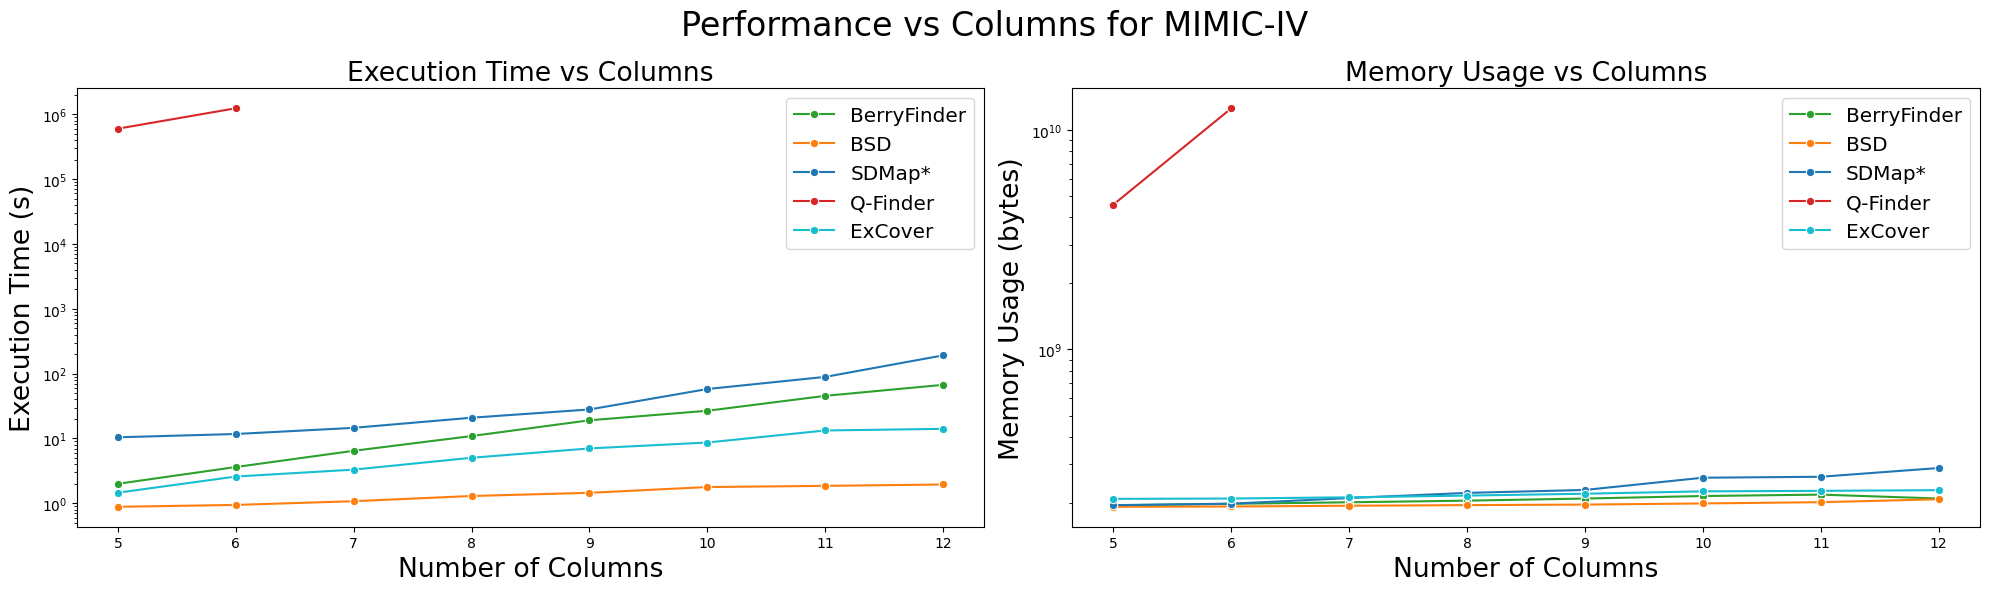

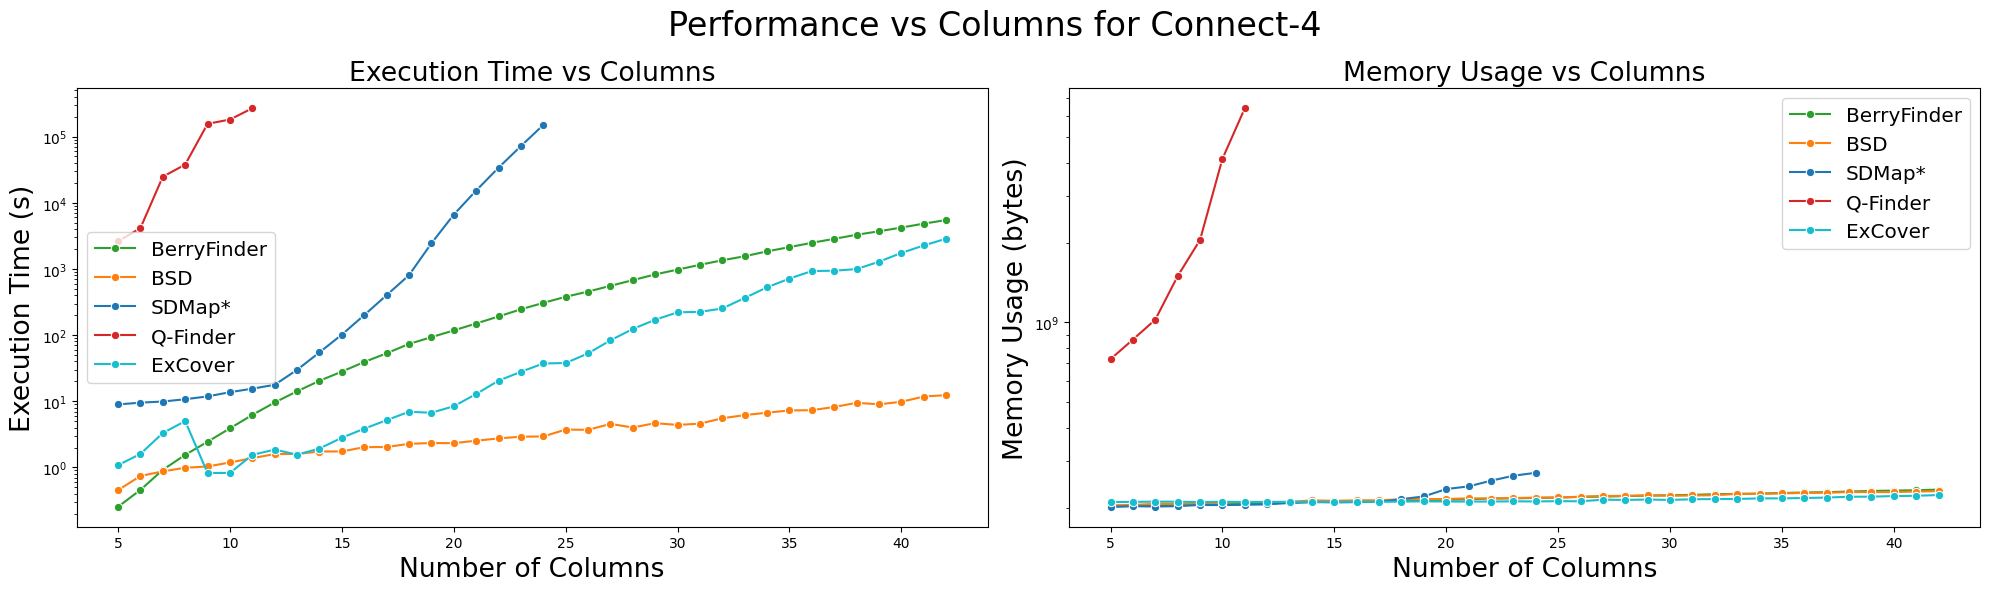

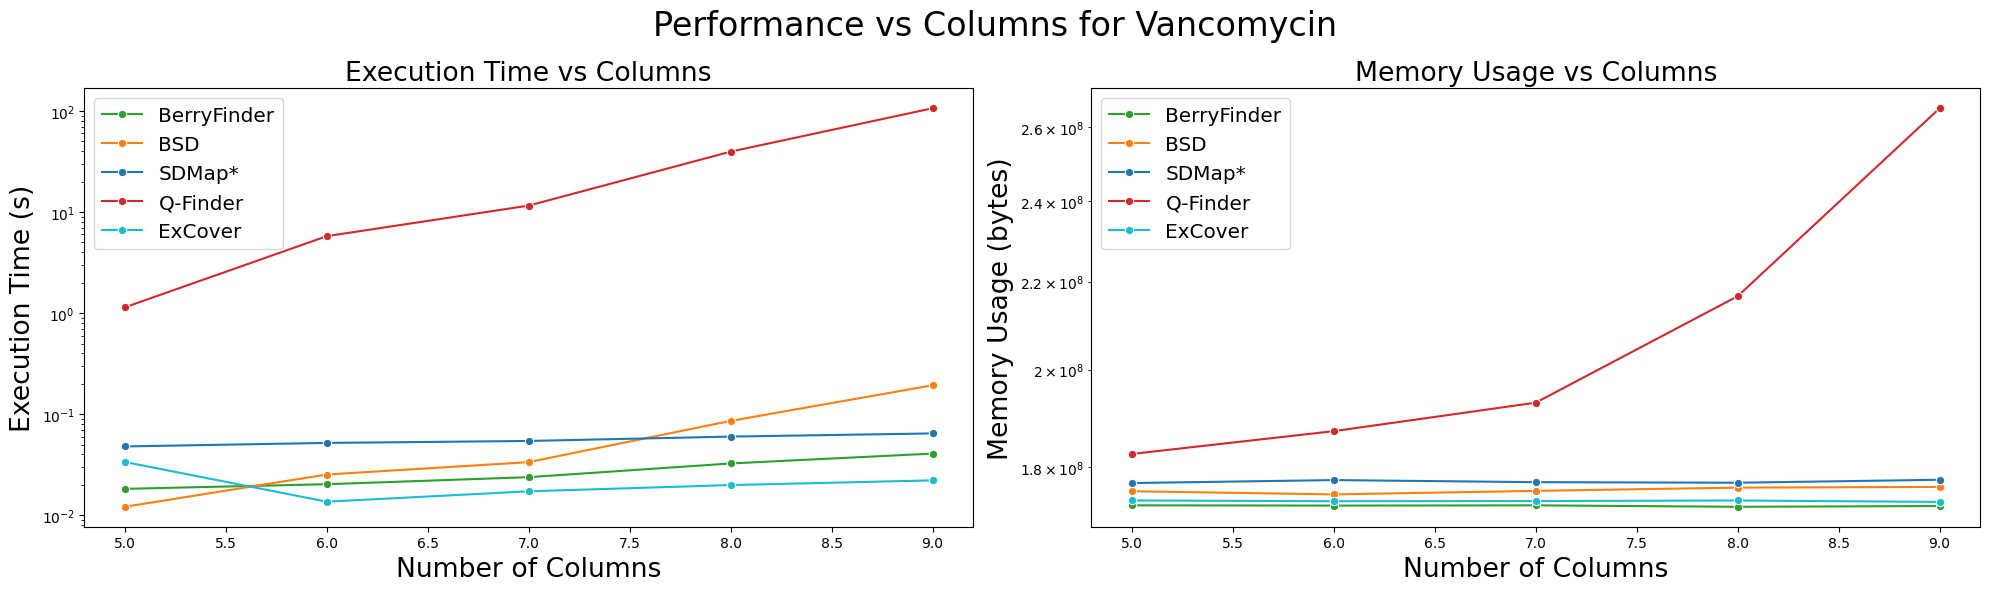

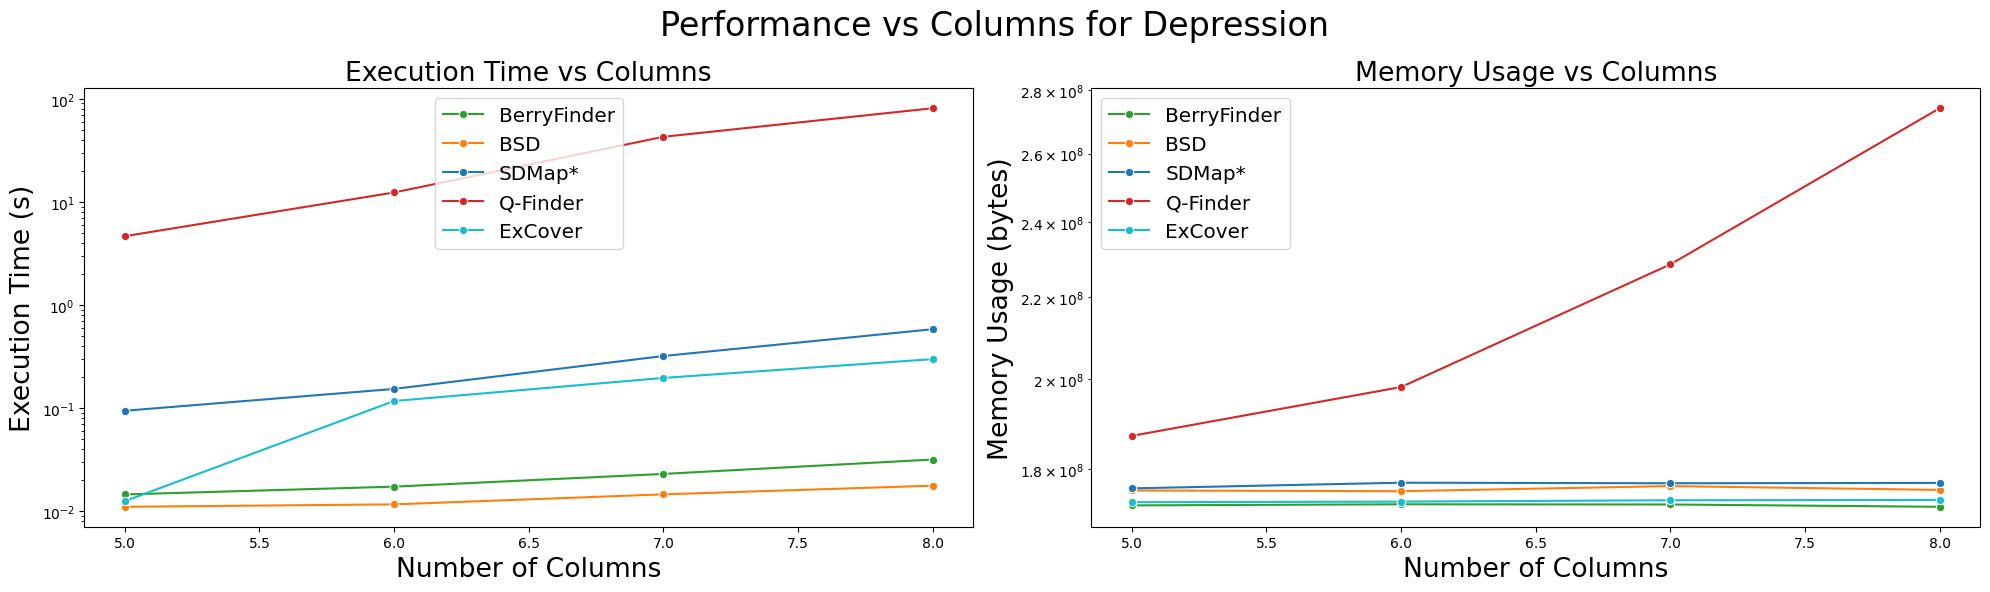

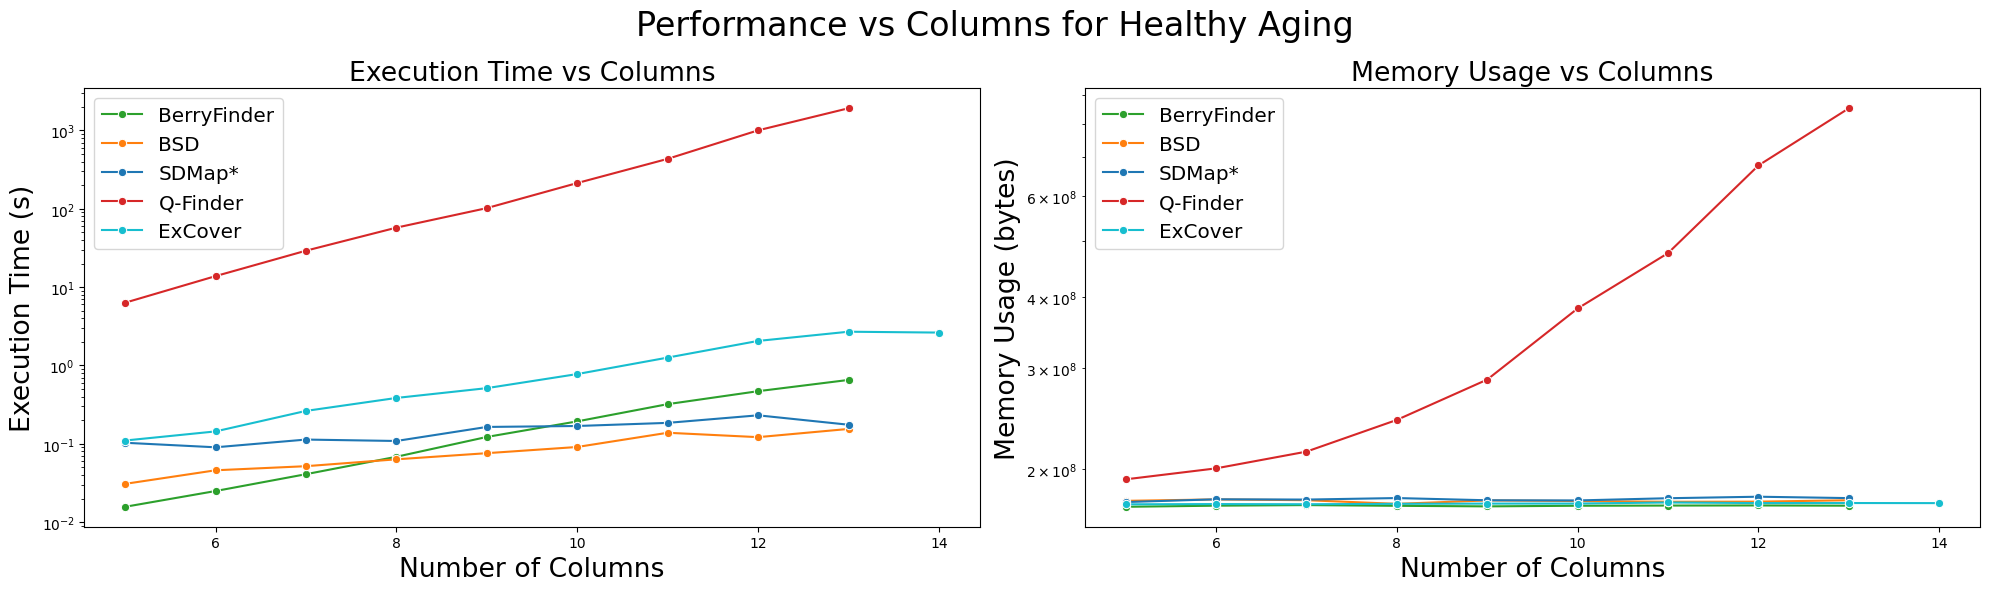

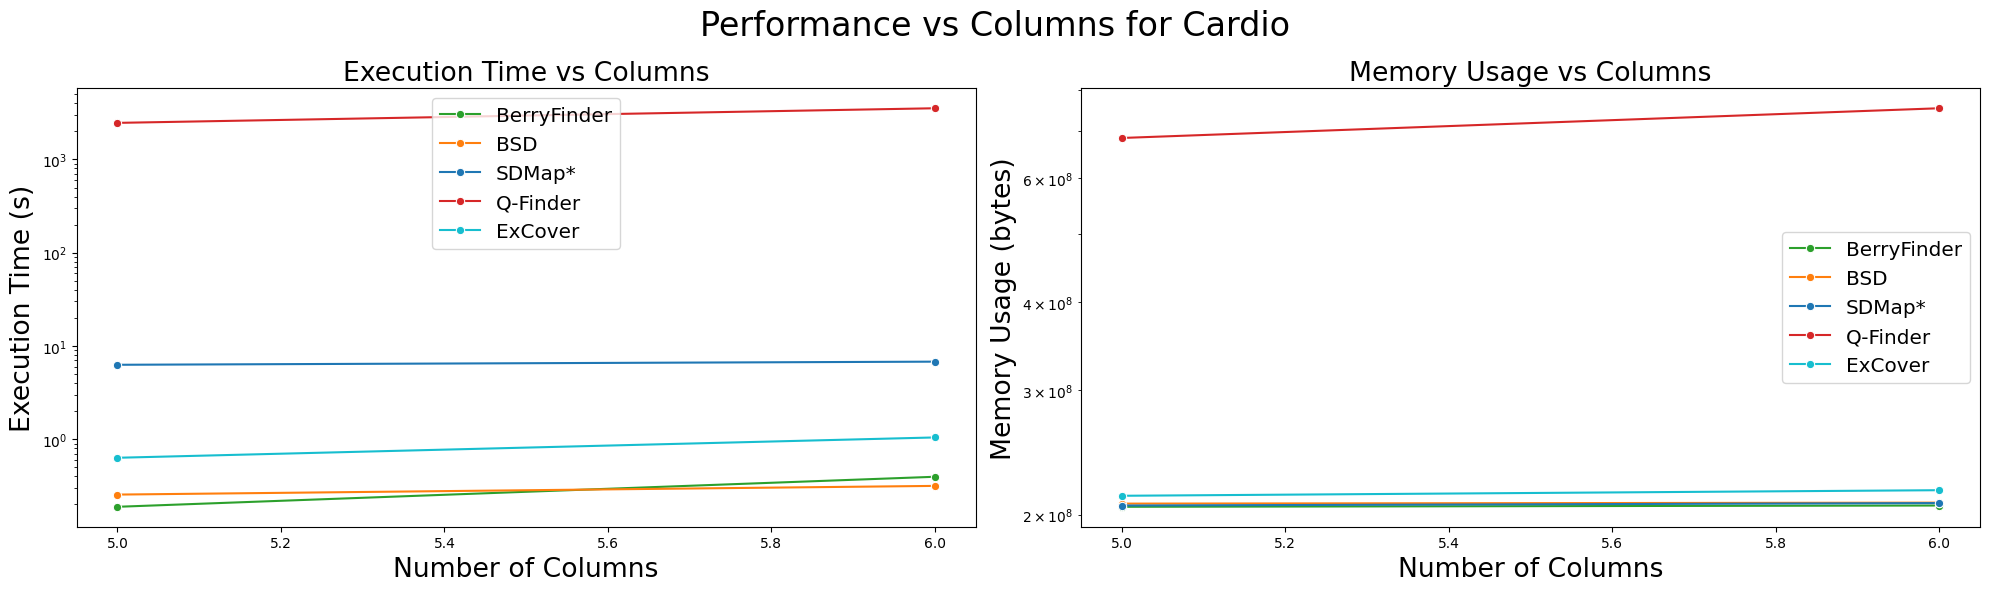

In [ ]:
palette = {
    "Q-Finder": "tab:red",
    "BerryFinder": "tab:green",
    "SDMap*": "tab:blue",
    "BSD" : "tab:orange",
    "BerryFinderNoPrune": "tab:purple",
    "ExCover" : "tab:cyan"
}

legend_order = ["BerryFinder", "BSD", "SDMap*", "Q-Finder", "ExCover"]

appendix_plots_order = ["Car Evaluation", "Cardio", "Chess", "Connect-4", "Depression", "Healthy Aging", "Mushrooms", "Student Success", "Vancomycin"]


for dataset in df["Dataset"].unique():
    if dataset == "Soybean":
        continue
    df_d = df[df["Dataset"] == dataset]
    # Subplots with time and memory
    fig, ax = plt.subplots(1,2,figsize=(20, 6))
    fontsize = 24
    fig.suptitle(f"Performance vs Columns for {dataset}", fontsize=fontsize)
    sns.lineplot(data=df_d, x="Columns", y="Time (s)", hue="Model", marker="o", palette=palette, hue_order=legend_order, ax=ax[0])
    ax[0].set_title(f"Execution Time vs Columns", fontsize=fontsize*0.8)
    ax[0].set_xlabel("Number of Columns", fontsize=fontsize*0.8)
    ax[0].set_ylabel("Execution Time (s)", fontsize=fontsize*0.8)
    ax[0].set_yscale("log")
    ax[0].legend(title="", fontsize=fontsize*0.6)
    sns.lineplot(data=df_d, x="Columns", y="Memory (bytes)", hue="Model", marker="o", palette=palette, hue_order=legend_order, ax=ax[1])
    ax[1].set_title(f"Memory Usage vs Columns", fontsize=fontsize*0.8)
    ax[1].set_xlabel("Number of Columns", fontsize=fontsize*0.8)
    ax[1].set_ylabel("Memory Usage (bytes)", fontsize=fontsize*0.8)
    ax[1].set_yscale("log")
    ax[1].legend(title="", fontsize=fontsize*0.6)
    fig.tight_layout()
    if dataset != "MIMIC-IV" and dataset != "Dermatology":
        # plt.savefig(f"./Appendix_A_plots/performance_columns_{dataset}.png", bbox_inches='tight')
        idx = appendix_plots_order.index(dataset) +7
        plt.savefig(f"./Appendix_A_plots/Fig{idx}.png", bbox_inches='tight')

    

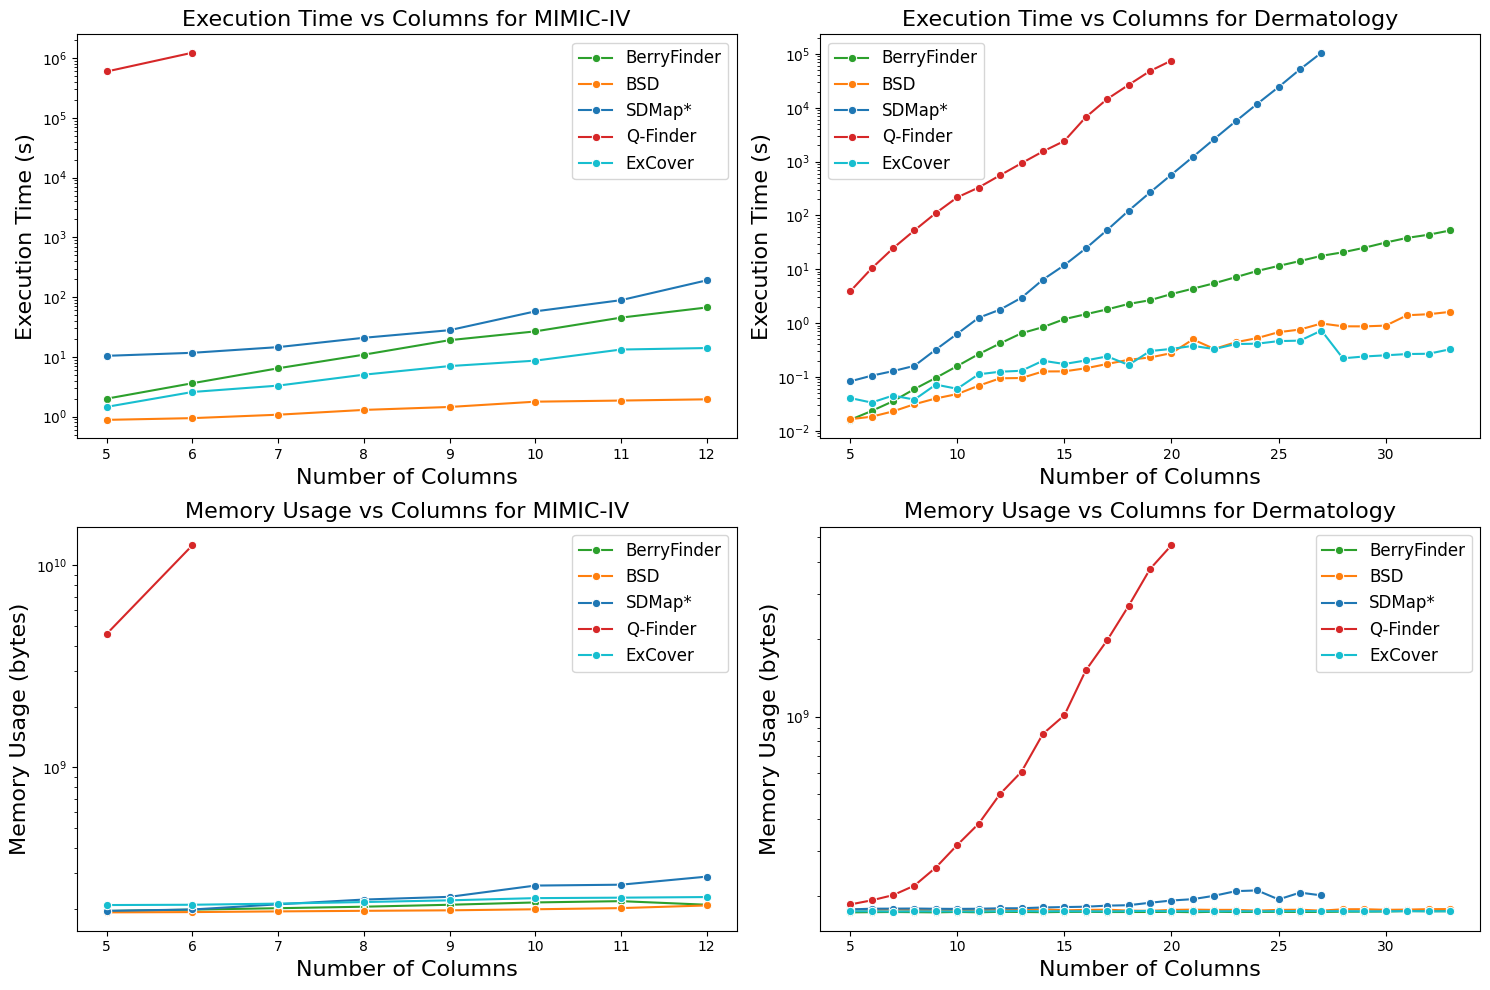

In [15]:
multiple_plots = ["MIMIC-IV", "Dermatology"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fontsize = 16

for dataset in multiple_plots:
    df_d = df[df["Dataset"] == dataset]
    ax_time = axes[0, 0] if dataset == multiple_plots[0] else axes[0, 1]
    ax_memory = axes[1, 0] if dataset == multiple_plots[0] else axes[1, 1]

    sns.lineplot(data=df_d, x="Columns", y="Time (s)", hue="Model", marker="o", palette=palette, hue_order=legend_order, ax=ax_time)
    ax_time.set_title(f"Execution Time vs Columns for {dataset}", fontsize=fontsize)
    ax_time.set_xlabel("Number of Columns", fontsize=fontsize)
    ax_time.set_ylabel("Execution Time (s)", fontsize=fontsize)
    ax_time.set_yscale("log")
    ax_time.legend(title="", fontsize=fontsize*0.75, title_fontsize=fontsize*0.85)

    sns.lineplot(data=df_d, x="Columns", y="Memory (bytes)", hue="Model", marker="o", palette=palette, hue_order=legend_order, ax=ax_memory)
    ax_memory.set_title(f"Memory Usage vs Columns for {dataset}", fontsize=fontsize)
    ax_memory.set_xlabel("Number of Columns", fontsize=fontsize)
    ax_memory.set_ylabel("Memory Usage (bytes)", fontsize=fontsize)
    ax_memory.set_yscale("log")
    ax_memory.legend(title="", fontsize=fontsize*0.75, title_fontsize=fontsize*0.85)
plt.tight_layout()
